<a href="https://colab.research.google.com/github/JJsupercoder/GIS-Green-Area-Coverage/blob/main/NDVI_Calculation_using_satellite_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Installing Required Libraries - Rasterio

In [ ]:
!pip install rasterio

#Downloading and unziping the specific Landsat Satellite Band Data

In [ ]:
!unzip /content/year1.zip -d /content/

Archive:  /content/year1.zip
  inflating: /content/L4-5_2009_10_23_B4_NIR.tif  
  inflating: /content/L4-5_2009_10_23_B3_RED.tif  
  inflating: /content/L4-5_2009_02_25_B4_NIR.tif  
  inflating: /content/L4-5_2009_02_25_B3_RED.tif  


In [ ]:
!unzip /content/year2.zip -d /content/

Archive:  /content/year2.zip
  inflating: /content/L4-5_2008_10_20_B4_NIR.tif  
  inflating: /content/L4-5_2008_04_11_B4_NIR.tif  
  inflating: /content/L4-5_2008_10_20_B3_RED.tif  
  inflating: /content/L4-5_2008_04_11_B3_RED.tif  


#Calculating NDVI using the NIR and RED Band Data

In [ ]:
import rasterio
import numpy as np
from matplotlib import pyplot as plt

## Copy Paste the path of the files uploaded

RED_year1_month1_path = "/content/L05_2010_04_01_B3_RED.tif"
NIR_year1_month1_path = "/content/L05_2010_04_01_B4_NIR.tif"

RED_year1_month2_path = "/content/L05_2010_10_26_B3_RED.tif"
NIR_year1_month2_path = "/content/L05_2010_10_26_B4_NIR.tif"

RED_year2_month1_path = "/content/L05_2011_02_15_B3_RED.tif"
NIR_year2_month1_path = "/content/L05_2011_02_15_B4_NIR.tif"

RED_year2_month2_path = "/content/L05_2011_11_14_B3_RED.tif"
NIR_year2_month2_path = "/content/L05_2011_11_14_B4_NIR.tif"


def get_band(path):
    with rasterio.open(path) as tif_file:
        print(f"Number of bands: {tif_file.count}")
        print(f"Size of the image: {tif_file.width} x {tif_file.height}")

        band1 = tif_file.read(1)
    return band1


In [ ]:
RED_year1_month1 = get_band(RED_year1_month1_path)
NIR_year1_month1 = get_band(NIR_year1_month1_path)

RED_year1_month2 = get_band(RED_year1_month2_path)
NIR_year1_month2 = get_band(NIR_year1_month2_path)

RED_year2_month1 = get_band(RED_year2_month1_path)
NIR_year2_month1 = get_band(NIR_year2_month1_path)

RED_year2_month2 = get_band(RED_year2_month2_path)
NIR_year2_month2 = get_band(NIR_year2_month2_path)

Number of bands: 1
Size of the image: 23 x 18
Number of bands: 1
Size of the image: 23 x 18
Number of bands: 1
Size of the image: 23 x 18
Number of bands: 1
Size of the image: 23 x 18
Number of bands: 1
Size of the image: 23 x 18
Number of bands: 1
Size of the image: 23 x 18
Number of bands: 1
Size of the image: 23 x 18
Number of bands: 1
Size of the image: 23 x 18


In [ ]:
print(np.max(RED_year1_month1), np.min(RED_year1_month1))
print(np.max(NIR_year1_month1), np.min(NIR_year1_month1))
print(np.max(RED_year1_month2), np.min(RED_year1_month2))
print(np.max(NIR_year1_month2), np.min(NIR_year1_month2))

print(np.max(RED_year2_month1), np.min(RED_year2_month1))
print(np.max(NIR_year2_month1), np.min(NIR_year2_month1))
print(np.max(RED_year2_month2), np.min(RED_year2_month2))
print(np.max(NIR_year2_month2), np.min(NIR_year2_month2))

25081 0
26522 0
17694 0
20002 0
15434 0
18363 0
13227 0
17309 0


In [ ]:
def calc_ndvi(NIR, RED):
    ndvi = np.divide(np.subtract(NIR, RED), np.add(NIR, RED))
    ndvi = np.nan_to_num(ndvi)
    return ndvi

month1_year1_ndvi = calc_ndvi(NIR_year1_month1, RED_year1_month1)
month2_year1_ndvi = calc_ndvi(NIR_year1_month2, RED_year1_month2)

month1_year2_ndvi = calc_ndvi(NIR_year2_month1, RED_year2_month1)
month2_year2_ndvi = calc_ndvi(NIR_year2_month2, RED_year2_month2)

<ipython-input-9-b194a2614905>:2: RuntimeWarning: invalid value encountered in divide
  ndvi = np.divide(np.subtract(NIR, RED), np.add(NIR, RED))


#Displaying the NDVI map of the Somaiya Campus
##(Each Pixel corresponds to a 30 sq meter area in the campus)

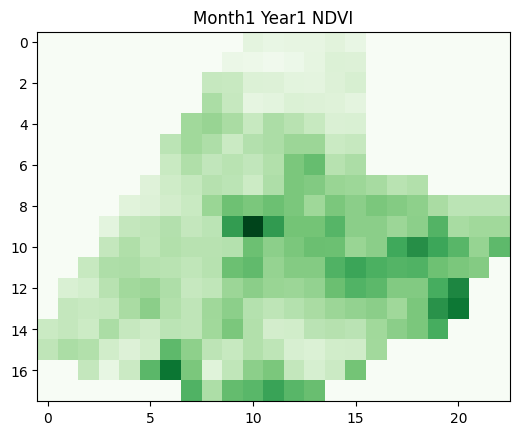

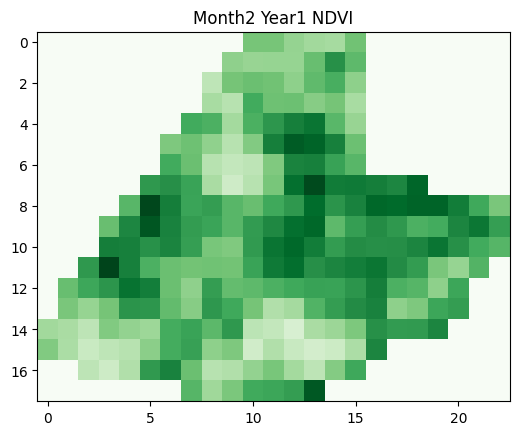

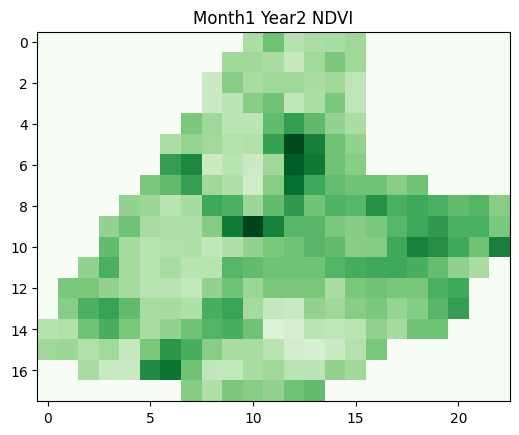

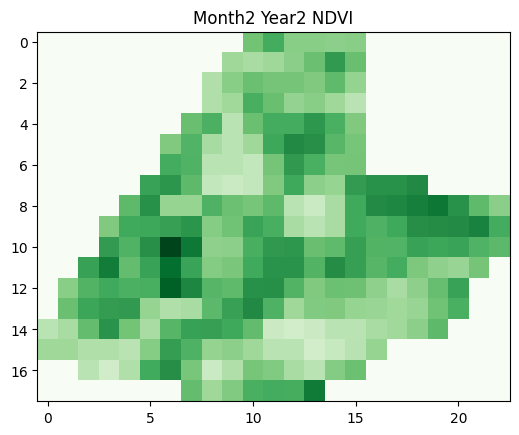

In [ ]:
def show_bw_image(img_gray, title=''):
    #show the grayscale image
    plt.imshow(img_gray, cmap=plt.get_cmap('Greens'))
    plt.title(title)
    plt.show()

show_bw_image(month1_year1_ndvi, "Month1 Year1 NDVI")
show_bw_image(month2_year1_ndvi, "Month2 Year1 NDVI")
show_bw_image(month1_year2_ndvi, "Month1 Year2 NDVI")
show_bw_image(month2_year2_ndvi, "Month2 Year2 NDVI")

#Understanding the distribution of NDVI values

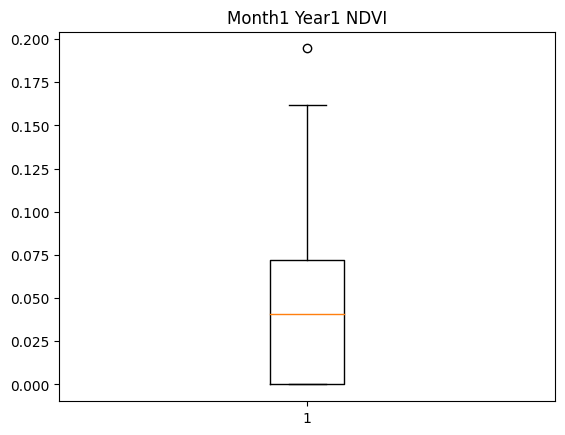

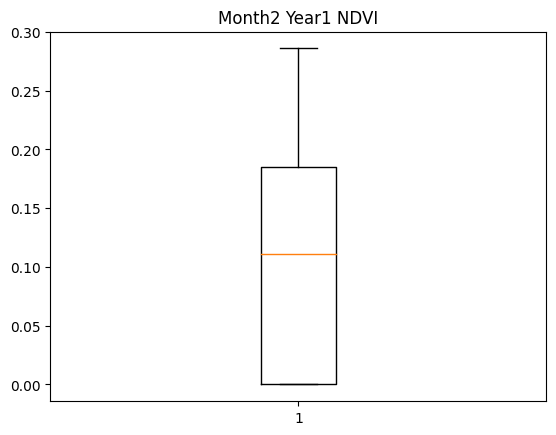

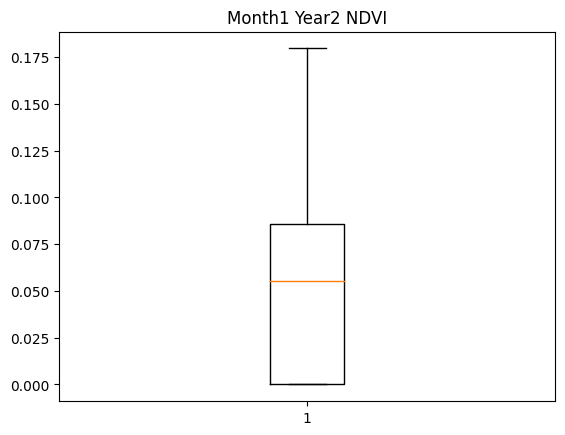

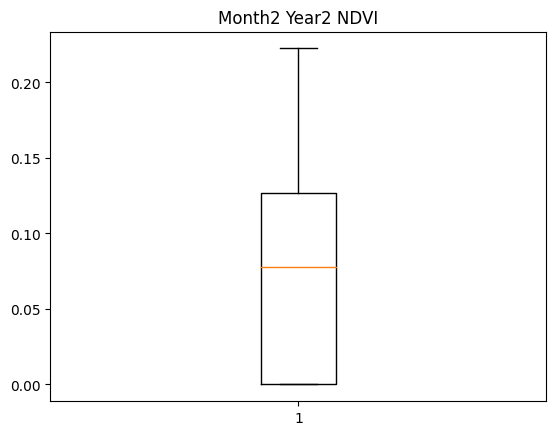

In [ ]:
def box_plot(ndvi_arr, title=""):
    data = ndvi_arr.flatten()
    fig = plt.figure()
    plt.boxplot(data)
    plt.title(title)
    plt.show()

box_plot(month1_year1_ndvi, "Month1 Year1 NDVI")
box_plot(month2_year1_ndvi, "Month2 Year1 NDVI")
box_plot(month1_year2_ndvi, "Month1 Year2 NDVI")
box_plot(month2_year2_ndvi, "Month2 Year2 NDVI")

#Calculating the various quantile values, the mean and the median for the NDVI map data


In [ ]:
x1 = list(np.quantile(month1_year1_ndvi, [0,0.25,0.5,0.75,1]))
x2 = list(np.quantile(month2_year1_ndvi, [0,0.25,0.5,0.75,1]))

x3 = list(np.quantile(month1_year2_ndvi, [0,0.25,0.5,0.75,1]))
x4 = list(np.quantile(month2_year2_ndvi, [0,0.25,0.5,0.75,1]))


In [ ]:
mean1 = np.mean(month1_year1_ndvi)
mean2 = np.mean(month2_year1_ndvi)
mean3 = np.mean(month1_year2_ndvi)
mean4 = np.mean(month2_year2_ndvi)

median1 = np.median(month1_year1_ndvi)
median2 = np.median(month2_year1_ndvi)
median3 = np.median(month1_year2_ndvi)
median4 = np.median(month2_year2_ndvi)


In [ ]:
x1.extend([mean1, median1])
x2.extend([mean2, median2])

x3.extend([mean3, median3])
x4.extend([mean4, median4])


In [ ]:
print(x1,x2,x3,x4, sep='\n')

[0.0, 0.0, 0.04080392975361776, 0.07225300783880133, 0.19450912250217203, 0.04113546359318092, 0.04080392975361776]
[0.0, 0.0, 0.11064399586461399, 0.1853297970060568, 0.28582061778935614, 0.10089823430422448, 0.11064399586461399]
[0.0, 0.0, 0.05528161731682153, 0.08569383383285843, 0.1796071094480823, 0.04935508336275706, 0.05528161731682153]
[0.0, 0.0, 0.07794374702049897, 0.12671318239940696, 0.22243017055686995, 0.06970002479074615, 0.07794374702049897]


Each of the array above is of the following format:

> [min, 1st_quartile, 2nd_quartile, 3rd_quartile, max, mean, median]



#Converting the data into a suitable format to store it in an Excel sheet

In [ ]:
!pip install pandas

In [ ]:
import pandas as pd

data = {
  "Min value": [x1[0], x2[0], x3[0], x4[0]],
  "Quartile1": [x1[1], x2[1], x3[1], x4[1]],
  "Quartile2": [x1[2], x2[2], x3[2], x4[2]],
  "Quartile3": [x1[3], x2[3], x3[3], x4[3]],
  "Max value": [x1[4], x2[4], x3[4], x4[4]],
  "Mean": [x1[5], x2[5], x3[5], x4[5]],
  "Median": [x1[6], x2[6], x3[6], x4[6]],
}

#load data into a DataFrame object:
df = pd.DataFrame(data)
df.index = ["Month1 Year1 NDVI", "Month2 Year1 NDVI", "Month1 Year2 NDVI", "Month2 Year2 NDVI"]
print(df.to_markdown())

|                   |   Min value |   Quartile1 |   Quartile2 |   Quartile3 |   Max value |      Mean |    Median |
|:------------------|------------:|------------:|------------:|------------:|------------:|----------:|----------:|
| Month1 Year1 NDVI |           0 |           0 |   0.0408039 |   0.072253  |    0.194509 | 0.0411355 | 0.0408039 |
| Month2 Year1 NDVI |           0 |           0 |   0.110644  |   0.18533   |    0.285821 | 0.100898  | 0.110644  |
| Month1 Year2 NDVI |           0 |           0 |   0.0552816 |   0.0856938 |    0.179607 | 0.0493551 | 0.0552816 |
| Month2 Year2 NDVI |           0 |           0 |   0.0779437 |   0.126713  |    0.22243  | 0.0697    | 0.0779437 |
